In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import QuantileRegressor
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn_quantile import RandomForestQuantileRegressor

# Dataset creation

In [2]:
# Random Generator initialization
seed = 42
rng = np.random.default_rng(seed)

In [3]:
# Toy dataset generation
n_samples = 300
constant_noise = 5  # arbitrary units, constant in x
growing_noise = 15  # arbitrary units, growing as a function of x
X, y = make_regression(n_samples=n_samples, n_features=1, noise=constant_noise, random_state=seed)

# Introduce growing variance in y as a function of x
noise = X.flatten() * rng.standard_normal(n_samples) * growing_noise
y = y + noise

In [4]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=seed)

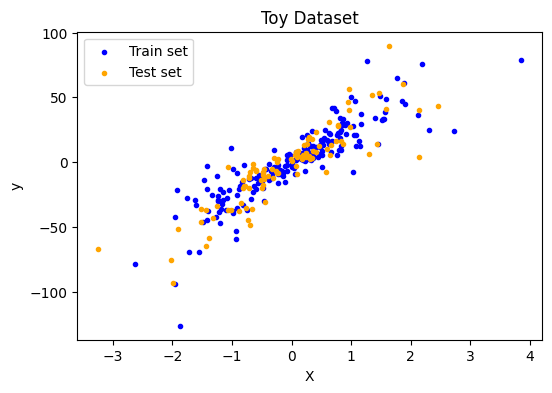

In [5]:
# Scatter plot of X vs y
plt.figure(figsize=(6, 4))
plt.scatter(X_train, y_train, marker=".", color="blue", label="Train set")
plt.scatter(X_test, y_test, marker=".", color="orange", label="Test set")
plt.title("Toy Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Bootstrapping



In [6]:
# Fit a model and predict on the Test set
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [7]:
# Define the number of bootstrap samples
n_samples = 1000

# Initialize predictions of bootstrapped models
predictions = np.zeros((n_samples, len(X_test)))

# Perform bootstrapping
for i in range(n_samples):
    # Generate one bootstraped sample, fit and store predictions
    X_resampled, y_resampled = resample(X_train, y_train, random_state=seed+i) # the seed needs to change at every iteration
    model.fit(X_resampled, y_resampled)
    predictions[i, :] = model.predict(X_test)

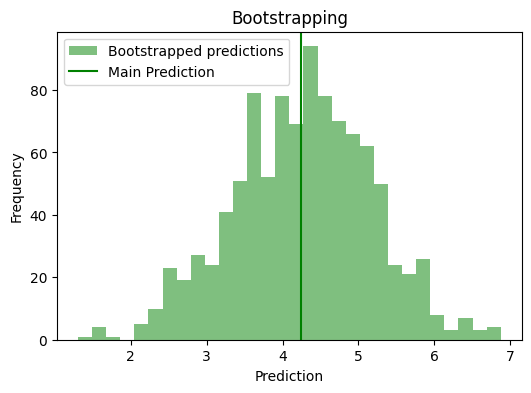

In [8]:
# Choose an example to plot
example_index = 0  

# Plot the distribution of the predictions for one example
plt.figure(figsize=(6, 4))
plt.hist(predictions[:, example_index], bins=30, alpha=0.5, color= "green", label="Bootstrapped predictions")
plt.axvline(x=y_pred[example_index] , color="green", linestyle="-", label="Main Prediction")
plt.xlabel("Prediction")
plt.ylabel("Frequency")
plt.title("Bootstrapping")
plt.legend()
plt.show()

In [9]:
# Calculate the confidence bounds
alpha = 0.1  # 90% confidence interval
lower_bound = np.quantile(predictions, alpha/2, axis=0)
upper_bound = np.quantile(predictions, 1-alpha/2, axis=0)

# Create a DataFrame with the required columns
df_results = pd.DataFrame({
    "X_test": X_test.flatten(),
    "y_test": y_test,
    "y_pred": y_pred,
    "lower_bound": lower_bound,
    "upper_bound": upper_bound
})

In [10]:
# Explore the results
df_results.head()

,X_test,y_test,y_pred,lower_bound,upper_bound
0,0.184634,5.537245,4.237757,2.682239,5.763369
1,-0.783253,-18.303170,-20.461461,-23.073871,-17.595259
2,1.307143,6.468566,32.882721,29.575318,36.173834
3,0.087047,4.197941,1.747470,0.196182,3.250620
4,0.954002,46.113212,23.871023,21.387446,26.438091


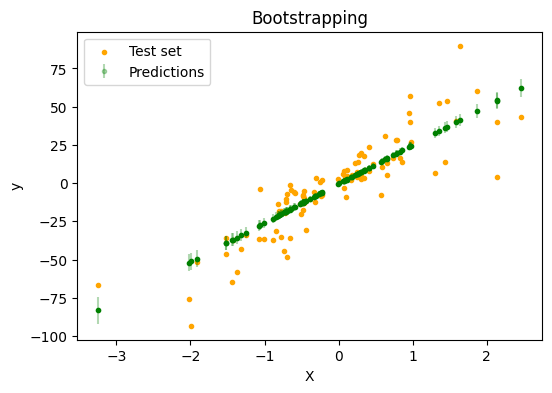

In [11]:
# Plot the original test data, predictions and their intervals
plt.figure(figsize=(6, 4))
plt.scatter(X_test, y_test, marker=".", color="orange", label="Test set")
plt.scatter(X_test, y_pred, marker=".", color="green")
plt.errorbar(X_test.flatten(), y_pred, yerr=[y_pred - lower_bound, upper_bound - y_pred], fmt=".", alpha=0.3, color="green", label="Predictions")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Bootstrapping")
plt.legend()
plt.show()

In [12]:
# Calculate coverage on the test dataset
coverage = np.sum((y_test >= lower_bound) & (y_test <= upper_bound)) / len(y_test)
print(f"Coverage: {coverage:.2f}")

Coverage: 0.19


# Ensemble methods

In this section we will use the library sklearn_quantile: https://pypi.org/project/sklearn-quantile/

Class RandomForestQuantileRegressor is based on N. Meinshausen, "Quantile Regression Forests", JMLR, 2006 
http://www.jmlr.org/papers/volume7/meinshausen06a/meinshausen06a.pdf

In [13]:
# Fit the Random Forest model on the training data
alpha = 0.1  # 90% confidence interval
model = RandomForestQuantileRegressor(min_samples_leaf=20, q=[alpha/2, 0.5, 1-alpha/2], random_state=seed)
model.fit(X_train, y_train)


,n_estimators,100
,q,"[0.05, 0.5, ...]"
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True


In [14]:
# Predict on the test set
results = model.predict(X_test)

# Unpack results
lower_bound = results[0, :]
y_pred = results[1, :]
upper_bound = results[2, :]

In [15]:
# Create a DataFrame with the predictions and intervals
pred_intervals = pd.DataFrame({
    "X_test": X_test.flatten(),
    "y_test": y_test,
    "y_pred": y_pred,
    "lower_bound": lower_bound,
    "upper_bound": upper_bound
})

In [16]:
# Display the prediction intervals DataFrame
pred_intervals.head()

,X_test,y_test,y_pred,lower_bound,upper_bound
0,0.184634,5.537245,5.735767,-5.020705,19.278927
1,-0.783253,-18.303170,-13.337369,-45.736919,-2.348028
2,1.307143,6.468566,30.098177,9.142070,73.550980
3,0.087047,4.197941,5.514106,-6.667209,19.136673
4,0.954002,46.113212,29.889475,9.119521,72.600914


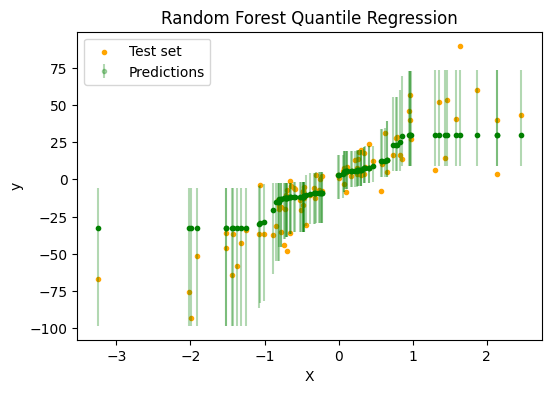

In [17]:
# Plot the original test data, predictions, and prediction intervals
plt.figure(figsize=(6, 4))
plt.scatter(X_test, y_test, marker=".", color="orange", label="Test set")
plt.scatter(X_test, y_pred, marker=".", color="green")
plt.errorbar(X_test.flatten(), y_pred, yerr=[y_pred - lower_bound, upper_bound - y_pred], fmt=".", alpha=0.3, color="green", label="Predictions")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Random Forest Quantile Regression")
plt.legend()
plt.show()

In [18]:
# Calculate coverage on the test dataset
coverage = np.sum((y_test >= lower_bound) & (y_test <= upper_bound)) / len(y_test)
print(f"Coverage: {coverage:.2f}")

Coverage: 0.91


# Quantile Regression

In [19]:
# Flatten X for compatibility with QuantileRegressor
X_train_flat = X_train.flatten()
X_test_flat = X_test.flatten()

In [20]:
# Fit the quantile regression models
alpha = 0.1  # 90% confidence interval
quantiles = [alpha/2, 0.5, 1-alpha/2]
models = {}
predictions = {}

for quantile in quantiles:
    model = QuantileRegressor(quantile=quantile, solver="highs", alpha=0)
    model.fit(X_train_flat[:, np.newaxis], y_train)
    models[quantile] = model
    predictions[quantile] = model.predict(X_test_flat[:, np.newaxis])

In [21]:
# Unpack predictions
lower_bound = predictions[quantiles[0]]
y_pred = predictions[quantiles[1]]
upper_bound = predictions[quantiles[2]]

# Convert the predictions to a DataFrame
predictions_df = pd.DataFrame({
    "X_test": X_test_flat,
    "y_test": y_test,
    "y_pred": y_pred,
    "upper_bound": upper_bound,
    "lower_bound": lower_bound
})

In [22]:
# Display the predictions DataFrame
predictions_df.head()

,X_test,y_test,y_pred,upper_bound,lower_bound
0,0.184634,5.537245,4.729847,25.274871,-18.611169
1,-0.783253,-18.303170,-19.140137,1.114049,-44.284245
2,1.307143,6.468566,32.413105,53.295429,11.163227
3,0.087047,4.197941,2.323167,22.838867,-21.199646
4,0.954002,46.113212,23.703960,44.480170,1.796210


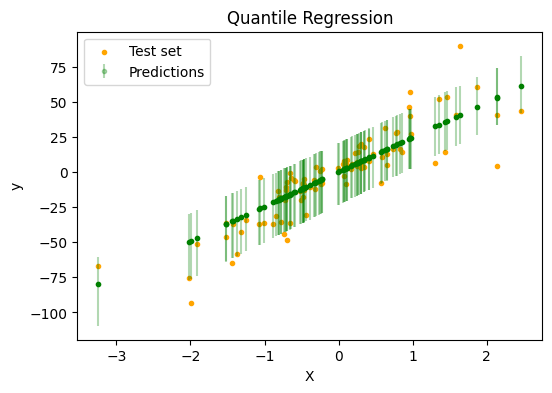

In [23]:
# Plot the original data and the quantile regression predictions
plt.figure(figsize=(6, 4))
plt.scatter(X_test, y_test, marker=".", color="orange", label="Test set")
plt.scatter(X_test, y_pred, marker=".", color="green")
plt.errorbar(X_test.flatten(), y_pred, yerr=[y_pred - lower_bound, upper_bound - y_pred], fmt=".", alpha=0.3, color="green", label="Predictions")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Quantile Regression")
plt.legend()
plt.show()

In [24]:
# Calculate coverage on the test dataset
coverage = np.sum((y_test >= lower_bound) & (y_test <= upper_bound)) / len(y_test)
print(f"Coverage: {coverage:.2f}")

Coverage: 0.89


# Conformal Prediction

In [25]:
# Split the training set into proper training and calibration sets
X_train_p, X_calibration, y_train_p, y_calibration = train_test_split(X_train, y_train, test_size=0.3, random_state=seed)

# Initialize the model
model = LinearRegression()

# Fit the model on the proper training set
model.fit(X_train_p, y_train_p)

# Predict on the calibration set
y_cal_pred = model.predict(X_calibration)

In [26]:
# Calculate nonconformity scores on the calibration set
nonconformity_scores = np.abs(y_calibration - y_cal_pred)

In [27]:
# Define the significance level
alpha = 0.1

# Calculate the quantile of nonconformity scores
quantile = np.quantile(nonconformity_scores, 1 - alpha)
print(f"Quantile: {quantile:.2f}")

Quantile: 23.56


In [28]:
# Predict on the test set and define confidence intervals
y_pred = model.predict(X_test)
lower_bound = y_pred - quantile
upper_bound = y_pred + quantile

# Create a DataFrame
pred_intervals = pd.DataFrame({
    "X_test": X_test.flatten(),
    "y_test": y_test,
    "y_pred": y_pred,
    "lower_bound": lower_bound,
    "upper_bound": upper_bound
})

# Display the prediction intervals DataFrame
pred_intervals.head()

,X_test,y_test,y_pred,lower_bound,upper_bound
0,0.184634,5.537245,4.250537,-19.304929,27.806003
1,-0.783253,-18.303170,-20.974219,-44.529685,2.581248
2,1.307143,6.468566,33.504994,9.949527,57.060460
3,0.087047,4.197941,1.707262,-21.848204,25.262729
4,0.954002,46.113212,24.301550,0.746083,47.857016


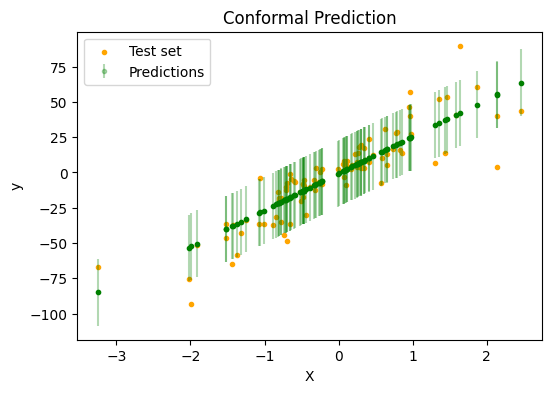

In [29]:
# Plot the original test data, predictions, and prediction intervals
plt.figure(figsize=(6, 4))
plt.scatter(X_test, y_test, color="orange", marker=".", label="Test set")
plt.scatter(X_test, y_pred, color="green", marker=".")
plt.errorbar(X_test.flatten(), y_pred, yerr=[y_pred - lower_bound, upper_bound - y_pred], color="green", fmt=".", alpha=0.3, label="Predictions")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Conformal Prediction")
plt.legend()
plt.show()

In [30]:
# Calculate coverage on the test dataset
coverage = np.sum((y_test >= lower_bound) & (y_test <= upper_bound)) / len(y_test)
print(f"Coverage: {coverage:.2f}")

Coverage: 0.91
